In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
import pandas as pd
import random

# Maan lijiye aapko sirf 10% data chahiye
p = 0.10

# Har row par ek random number 0 se 1 ke beech generate hoga
# Agar number p (0.10) se bada hai, toh us row ko skip kar dega
df = pd.read_csv(
    "2019-Nov.csv", 
    skiprows=lambda i: i > 0 and random.random() > p
)

In [12]:
df.shape

(6748900, 9)

EDA

In [10]:
df.head(5)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2
1,2019-11-01 00:00:03 UTC,view,17200570,2053013559792632471,furniture.living_room.sofa,NaN,437.33,518780843,aa806835-b14c-45af-9538-cd4d1849be3e
2,2019-11-01 00:00:06 UTC,view,24900193,2053013562183385881,NaN,NaN,1.09,512651494,f603c815-f51a-46fe-9404-cb586e35edaf
3,2019-11-01 00:00:08 UTC,view,1307115,2053013558920217191,computers.notebook,hp,411.59,514028527,df8184cc-3694-4549-8c8c-6b5171877376
4,2019-11-01 00:00:12 UTC,view,22700205,2053013556168753601,NaN,matrix,23.14,564599988,d67efe84-f47e-44dd-8abf-a9122c706acd


In [16]:
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='str')

In [9]:
df.isnull().sum(axis=0)

event_time             0
event_type             0
product_id             0
category_id            0
category_code    2189374
brand             922887
price                  0
user_id                0
user_session           1
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(2060)

In [ ]:
import pandas as pd
import hashlib

def keep_session(session_id, p=0.10):
    # Har session ID ka ek unique hash banata hai
    # Agar hash condition meet karta hai, toh us pure session ki saari rows keep karega
    if pd.isna(session_id): return False
    return int(hashlib.md5(session_id.encode('utf-8')).hexdigest(), 16) % 100 < (p * 100)

chunks = []
# 10 Lakh rows ek baar mein load karega (No RAM crash)
for chunk in pd.read_csv("2019-Nov.csv", chunksize=1000000):
    # Sirf un rows ko filter karega jinka session_id hamare 10% sample mein aata hai
    filtered_chunk = chunk[chunk['user_session'].apply(keep_session)]
    chunks.append(filtered_chunk)

# End mein saare filtered chunks ko combine kar lenge
final_df = pd.concat(chunks, ignore_index=True)

In [17]:
import pandas as pd
import hashlib

def keep_session(session_id, p=0.10):
    # Agar kisi wajah se session_id missing hai, toh usko turant reject kar do
    if pd.isna(session_id): 
        return False
    # Hashing se pehle explicitly str() lagaya hai taaki string/float conflict na aaye
    return int(hashlib.md5(str(session_id).encode('utf-8')).hexdigest(), 16) % 100 < (p * 100)

chunks = []

# Chunksize ke through 10 Lakh rows load kar rahe hain
for chunk in pd.read_csv("2019-Nov.csv", chunksize=1000000):
    
    # 1. DATA CLEANING: Wo 1 missing user_session wali row yahan turant drop ho jayegi
    chunk = chunk.dropna(subset=['user_session'])
    
    # Note: Hum 'brand' aur 'category_code' ke missing values ko drop NAHI kar rahe,
    # kyunki user ne agar unbranded item view kiya hai, toh bhi wo ML/GRU ke liye ek important action hai.
    
    # 2. FILTERING: Sirf 10% users ke sessions ko rakho
    filtered_chunk = chunk[chunk['user_session'].apply(keep_session)]
    
    chunks.append(filtered_chunk)

# Saare clean aur filtered chunks ko ek final DataFrame mein combine kar lo
final_df = pd.concat(chunks, ignore_index=True)

# Verification ke liye print kar sakte hain
print("Final Data Shape:", final_df.shape)

Final Data Shape: (6737885, 9)


In [33]:
final_df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:01 UTC,view,1306421,2053013558920217191,computers.notebook,hp,514.56,514028527,df8184cc-3694-4549-8c8c-6b5171877376
1,2019-11-01 00:00:03 UTC,view,16700260,2053013559901684381,furniture.kitchen.chair,NaN,31.64,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f
2,2019-11-01 00:00:08 UTC,view,1307115,2053013558920217191,computers.notebook,hp,411.59,514028527,df8184cc-3694-4549-8c8c-6b5171877376
3,2019-11-01 00:00:08 UTC,view,1004708,2053013555631882655,electronics.smartphone,huawei,151.99,566143627,aa610ab3-5c60-4551-8a2b-8c999dddf843
4,2019-11-01 00:00:12 UTC,view,16700826,2053013559901684381,furniture.kitchen.chair,nika,47.77,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f
5,2019-11-01 00:00:12 UTC,view,10800182,2053013554994348409,NaN,redmond,61.10,527322328,5054190a-46cb-4211-a8f1-16fc1a060ed8
6,2019-11-01 00:00:13 UTC,view,15200565,2053013553484398879,NaN,hyper,54.06,518758107,f617be3c-8447-4aaf-b9b7-2e23a21a8b58
7,2019-11-01 00:00:17 UTC,view,1800729,2053013554415534427,electronics.video.tv,samsung,289.33,515782589,f2081cf0-0ee3-4bf1-9b40-e5e580f9ace3
8,2019-11-01 00:00:18 UTC,view,16700826,2053013559901684381,furniture.kitchen.chair,nika,47.77,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f
9,2019-11-01 00:00:18 UTC,view,10701060,2053013561277416167,NaN,NaN,66.90,512996121,23375068-25db-44fd-86a8-52123e47e93e


In [3]:
final_df.to_csv('Filtered_dataset',index=False)

NameError: name 'final_df' is not defined

EDA

In [3]:
final_df=pd.read_csv('Filtered_dataset.csv')

In [4]:
final_df.duplicated().sum()

np.int64(10434)

In [22]:
Percentage_duplicated=(10434/(final_df.shape[0]))*100

In [23]:
Percentage_duplicated

0.1548557151094149

Very Low.Thus,We can Remove it

In [5]:
final_df = final_df.drop_duplicates()


In [27]:
final_df.shape[0]

6727451

In [26]:
final_df.isnull().sum()

event_time             0
event_type             0
product_id             0
category_id            0
category_code    2184325
brand             922756
price                  0
user_id                0
user_session           0
dtype: int64

Percentage of missing values:-

In [52]:
(final_df.isnull().sum()/final_df.shape[0])*100

event_time        0.000000
event_type        0.000000
product_id        0.000000
category_id       0.000000
category_code    32.468836
brand            13.716280
price             0.000000
user_id           0.000000
user_session      0.000000
dtype: float64

In [31]:
uv pip install missingno

Note: you may need to restart the kernel to use updated packages.


d:\CA_content\Python\Final_Project\.venv\Scripts\python.exe: No module named uv


In [78]:
# Data ko pehle User Session se group karo, aur fir us session ke andar Time ke hisaab se sort karo
final_df = final_df.sort_values(by=['user_session', 'event_time']).reset_index(drop=True)

In [36]:
final_df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-02 13:29:04 UTC,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e
1,2019-11-01 19:06:53 UTC,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
2,2019-11-01 19:07:11 UTC,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
3,2019-11-01 19:08:13 UTC,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
4,2019-11-01 19:09:55 UTC,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
5,2019-11-01 19:11:13 UTC,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
6,2019-11-01 19:12:49 UTC,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
7,2019-11-01 19:13:17 UTC,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
8,2019-11-01 19:14:07 UTC,view,5100855,2053013553341792533,electronics.clocks,apple,548.02,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
9,2019-11-01 19:14:58 UTC,view,1005073,2053013555631882655,electronics.smartphone,samsung,1133.09,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f


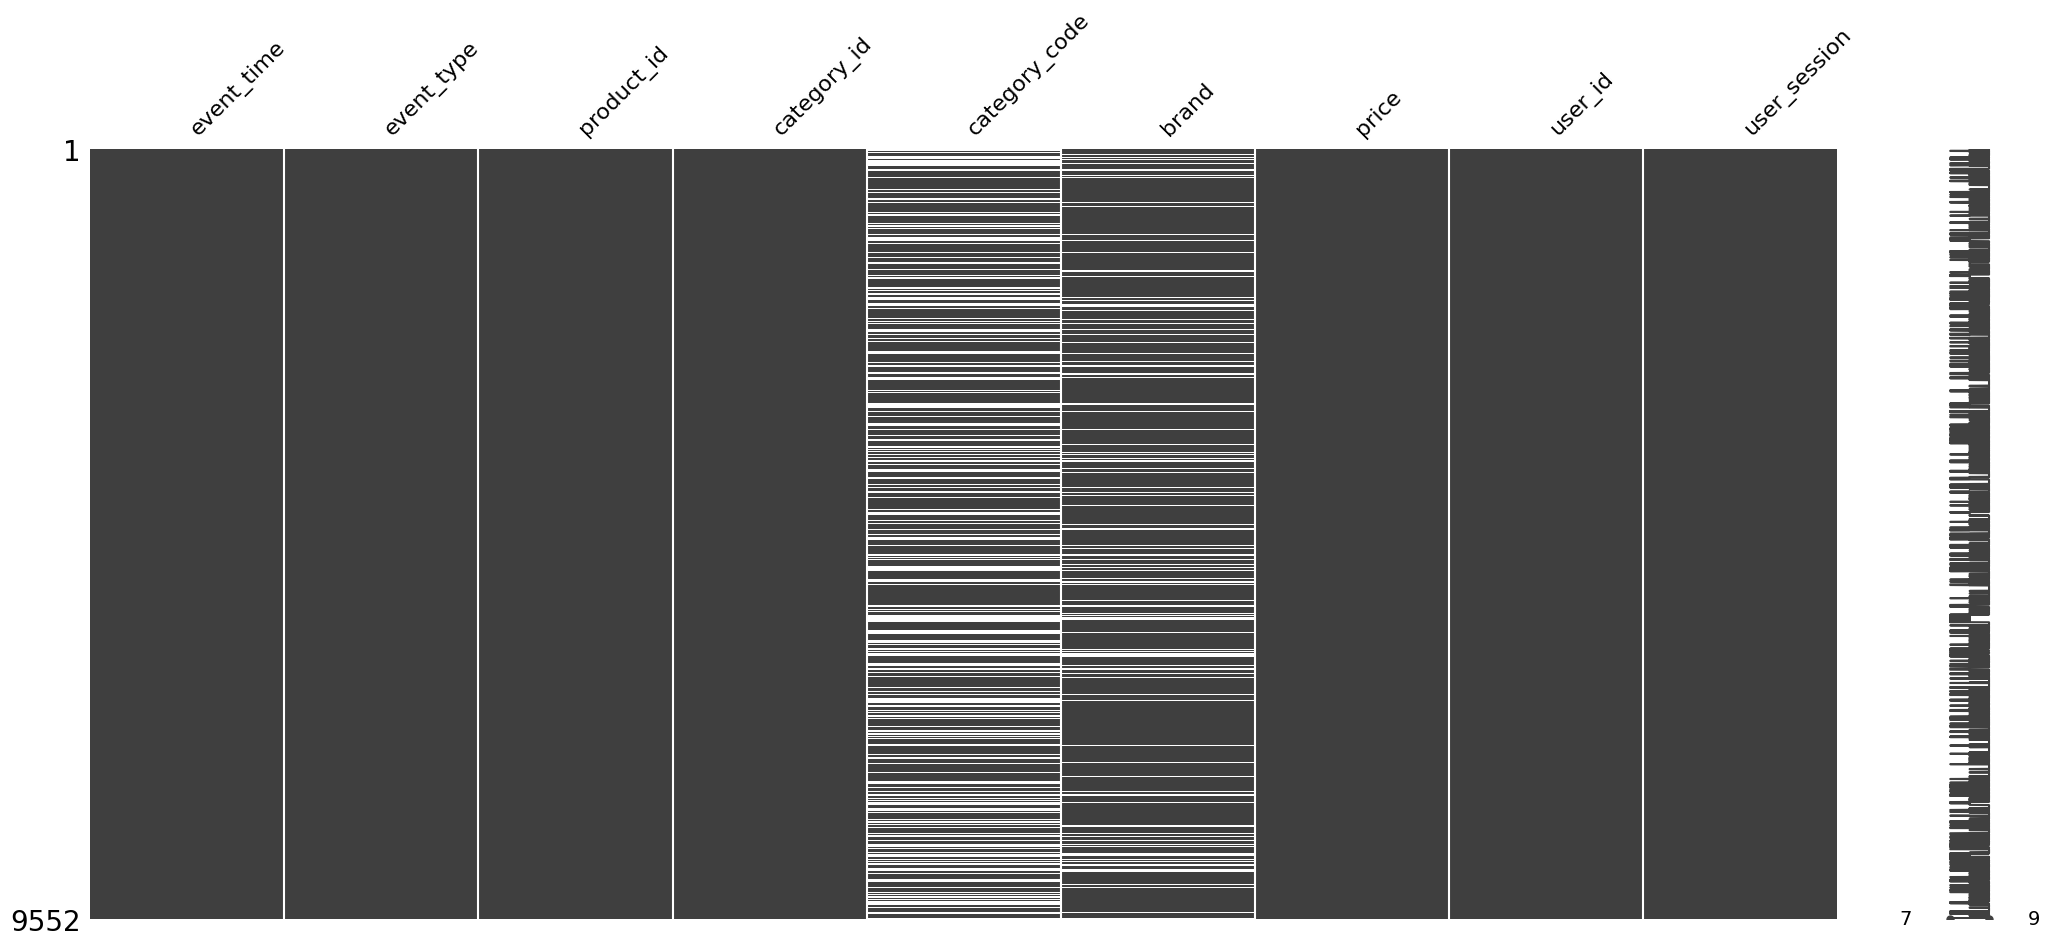

In [43]:
# 1. Pehle 1000 random aur unique 'user_session' IDs uthao
random_session_ids = pd.Series(final_df['user_session'].dropna().unique()).sample(2000, random_state=42)

# 2. Ab original dataframe se sirf un 1000 sessions ka PURA data filter kar lo
sample_df = final_df[final_df['user_session'].isin(random_session_ids)]

# 3. Ab plot karo (Ye perfect insights dega!)
msno.matrix(sample_df)
plt.show()

<Figure size 100x100 with 0 Axes>

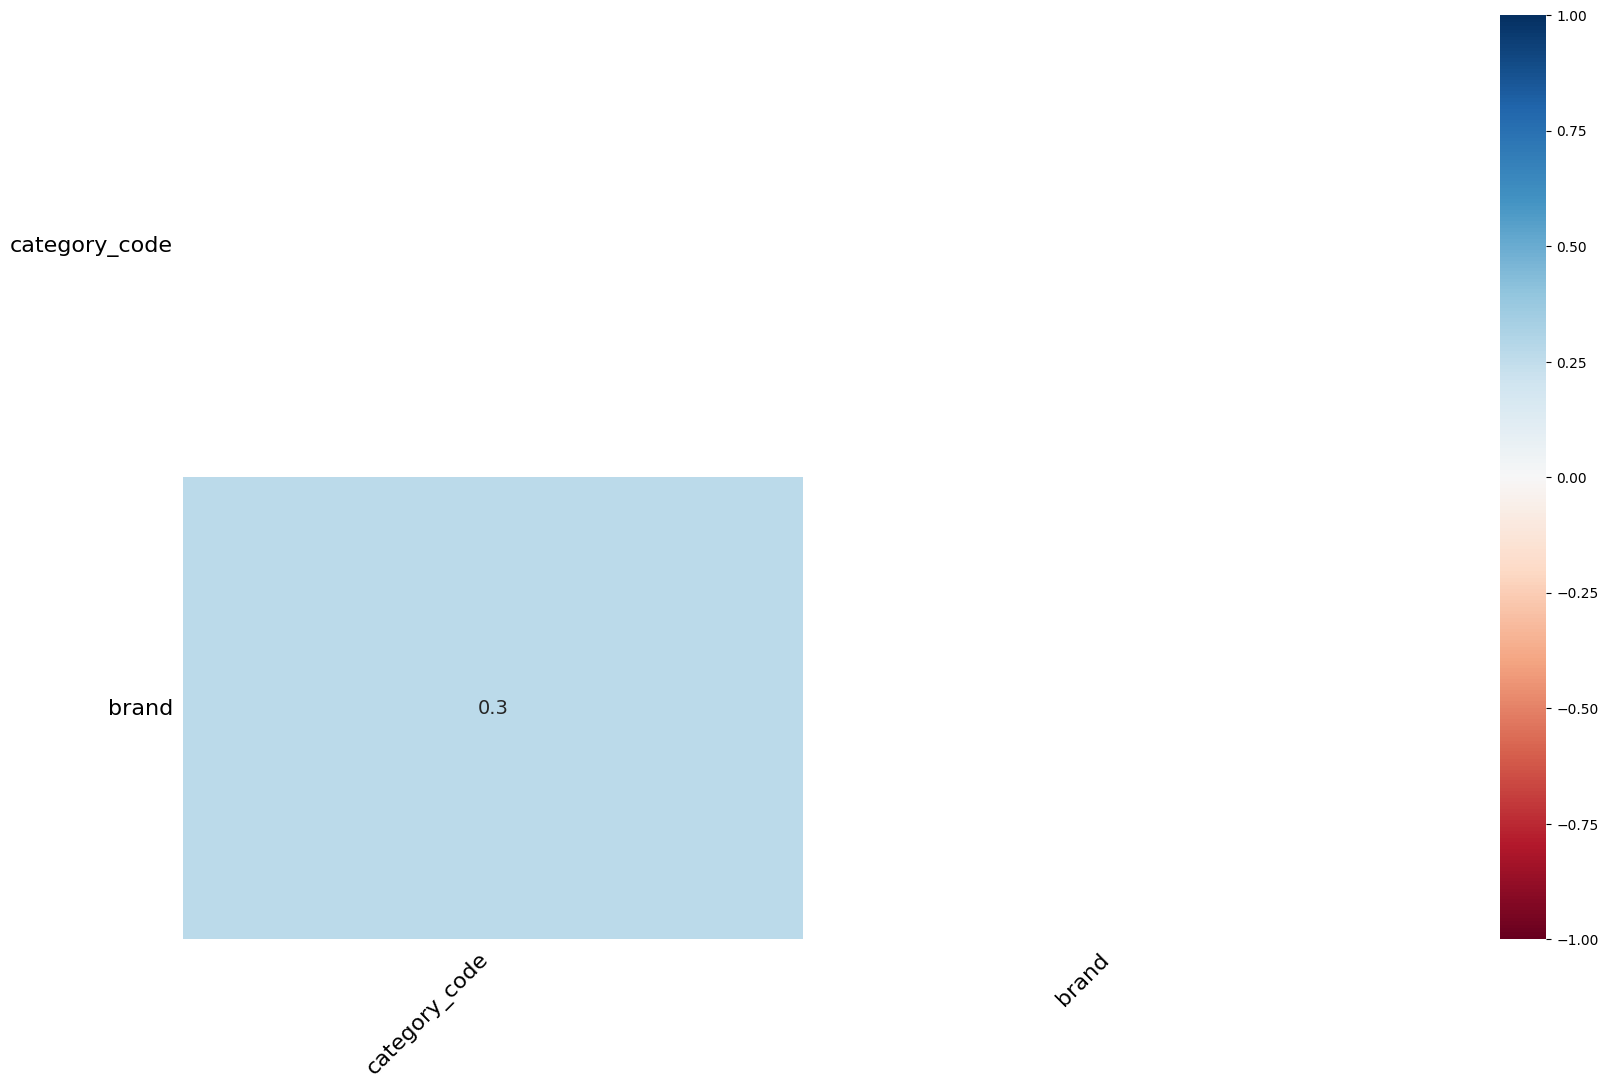

In [50]:

plt.figure(figsize=(1,1))
msno.heatmap(sample_df)
plt.show()

EK hypothesis lii h jisme hum kehte h ki har category id ke liye different category code h!

In [1]:
# STEP 1: Rule book (Dictionary) banate hain
category_map = final_df.dropna(subset=['category_code']).set_index('category_id')['category_code'].to_dict()

# STEP 2: NAYA COLUMN banate hain aur original ko waise hi chhod dete hain
final_df['category_code_filled'] = final_df['category_code']

# STEP 3: Sirf is NAYE COLUMN ki missing values ko apni dictionary se fill karte hain
final_df['category_code_filled'] = final_df['category_code_filled'].fillna(final_df['category_id'].map(category_map))

# STEP 4: Jo bilkul anjaan hain, unhe tag de dete hain
final_df['category_code_filled'] = final_df['category_code_filled'].fillna('unknown_category')

NameError: name 'final_df' is not defined

In [54]:
final_df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled
0,2019-11-02 13:29:04 UTC,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e,construction.tools.drill
1,2019-11-01 19:06:53 UTC,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone
2,2019-11-01 19:07:11 UTC,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone
3,2019-11-01 19:08:13 UTC,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone
4,2019-11-01 19:09:55 UTC,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone
5,2019-11-01 19:11:13 UTC,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone
6,2019-11-01 19:12:49 UTC,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone
7,2019-11-01 19:13:17 UTC,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone
8,2019-11-01 19:14:07 UTC,view,5100855,2053013553341792533,electronics.clocks,apple,548.02,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.clocks
9,2019-11-01 19:14:58 UTC,view,1005073,2053013555631882655,electronics.smartphone,samsung,1133.09,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone


In [55]:
# Ek aisi filter lagate hain jahan purana column Khali (NaN) tha, par naya column bhar gaya hai
magical_fills = final_df[final_df['category_code'].isnull() & (final_df['category_code_filled'] != 'unknown_category')]

# Dono columns ko aamne-saamne compare karke dekhte hain
print(magical_fills[['category_id', 'category_code', 'category_code_filled']].head(10))

Empty DataFrame
Columns: [category_id, category_code, category_code_filled]
Index: []


In [59]:
final_df[final_df['category_code'].isnull()]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled
10,2019-11-23 20:03:08 UTC,view,14400061,2053013558492398155,NaN,crown,10.18,512651600,0000189b-6d2d-45bc-a65c-3a9d94e330a4,unknown_category
11,2019-11-16 11:18:37 UTC,view,13700195,2053013557452210699,NaN,erlit,297.74,531142295,000029a6-1986-4a71-8139-53669c1adaba,unknown_category
12,2019-11-16 11:19:30 UTC,view,13700078,2053013557452210699,NaN,erlit,297.49,531142295,000029a6-1986-4a71-8139-53669c1adaba,unknown_category
13,2019-11-16 11:19:59 UTC,view,13700078,2053013557452210699,NaN,erlit,297.49,531142295,000029a6-1986-4a71-8139-53669c1adaba,unknown_category
14,2019-11-16 11:20:12 UTC,view,13700170,2053013557452210699,NaN,erlit,427.78,531142295,000029a6-1986-4a71-8139-53669c1adaba,unknown_category
...,...,...,...,...,...,...,...,...,...,...
6727378,2019-11-18 11:41:27 UTC,view,11400445,2053013558458843721,NaN,hoco,20.57,524900838,ffff5c3f-cae1-4692-abb3-59d27d3f9a0d,unknown_category
6727379,2019-11-18 11:41:45 UTC,view,11400445,2053013558458843721,NaN,hoco,20.57,524900838,ffff5c3f-cae1-4692-abb3-59d27d3f9a0d,unknown_category
6727380,2019-11-18 11:41:54 UTC,view,11400387,2053013558458843721,NaN,hoco,27.00,524900838,ffff5c3f-cae1-4692-abb3-59d27d3f9a0d,unknown_category
6727448,2019-11-19 12:03:27 UTC,view,7203478,2053013553165631753,NaN,lego,244.54,573454547,ffffcdf8-f820-4b22-acee-d8c425b624fc,unknown_category


In [60]:
category_map

{2053013556311359947: 'construction.tools.drill',
 2053013555631882655: 'electronics.smartphone',
 2053013553341792533: 'electronics.clocks',
 2053013552695869677: 'electronics.tablet',
 2172371436436455782: 'electronics.tablet',
 2053013557192163841: 'furniture.bedroom.bed',
 2053013554658804075: 'electronics.audio.headphone',
 2053013561579406073: 'electronics.clocks',
 2053013563944993659: 'appliances.kitchen.dishwasher',
 2053013556344914381: 'kids.fmcg.diapers',
 2053013565983425517: 'appliances.environment.vacuum',
 2053013554415534427: 'electronics.video.tv',
 2053013563810775923: 'appliances.kitchen.washer',
 2053013553090134275: 'kids.toys',
 2053013560899928785: 'auto.accessories.videoregister',
 2053013555262783879: 'appliances.kitchen.blender',
 2053013559792632471: 'furniture.living_room.sofa',
 2053013558316237377: 'furniture.kitchen.table',
 2053013553224352013: 'kids.dolls',
 2053013563911439225: 'appliances.kitchen.refrigerators',
 2053013558920217191: 'computers.noteb

Checking One Vs One Mapping

In [81]:
# STEP 1: Pehle wo data nikalte hain jahan category_code missing nahi hai
valid_cats_df = final_df.dropna(subset=['category_code'])

# STEP 2: Har product_id ke liye check karte hain ki uske paas kitne UNIQUE category codes hain
category_counts = valid_cats_df.groupby('product_id')['category_code'].nunique()

# STEP 3: Aise products filter karte hain jinki 1 se zyada categories hain (Inconsistent data)
inconsistent_products = category_counts[category_counts > 1]

# STEP 4: Result print karte hain
print(f"Total Unique Products: {len(category_counts)}")
print(f"Products with MULTIPLE categories: {len(inconsistent_products)}")

# Agar koi inconsistent product milta hai, toh uska data dekhte hain
if len(inconsistent_products) > 0:
    print("\nKuch inconsistent products ke IDs:")
    print(inconsistent_products.head())

Total Unique Products: 64889
Products with MULTIPLE categories: 0


In [79]:
final_df.head(4)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-02 13:29:04 UTC,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e
1,2019-11-01 19:06:53 UTC,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
2,2019-11-01 19:07:11 UTC,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
3,2019-11-01 19:08:13 UTC,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f


In [80]:
final_df.isnull().sum()

event_time             0
event_type             0
product_id             0
category_id            0
category_code    2184325
brand             922756
price                  0
user_id                0
user_session           0
dtype: int64

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled


In [6]:
# STEP 1: Product_ID se Category aur Brand ki perfect dictionaries banate hain
prod_cat_dict = final_df.dropna(subset=['category_code']).drop_duplicates('product_id').set_index('product_id')['category_code'].to_dict()
prod_brand_dict = final_df.dropna(subset=['brand']).drop_duplicates('product_id').set_index('product_id')['brand'].to_dict()

# STEP 2: NAYE COLUMNS banate hain aur unme mapped values fill karte hain
# (Original columns ko touch nahi kar rahe)
final_df['category_code_filled'] = final_df['category_code'].fillna(final_df['product_id'].map(prod_cat_dict))
final_df['brand_filled'] = final_df['brand'].fillna(final_df['product_id'].map(prod_brand_dict))


In [7]:
final_df.isnull().sum()

event_time                    0
event_type                    0
product_id                    0
category_id                   0
category_code           2184325
brand                    922756
price                         0
user_id                       0
user_session                  0
category_code_filled    2184325
brand_filled             891355
dtype: int64

In [85]:
final_df.head(4)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled
0,2019-11-02 13:29:04 UTC,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e,construction.tools.drill,bosch
1,2019-11-01 19:06:53 UTC,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple
2,2019-11-01 19:07:11 UTC,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple
3,2019-11-01 19:08:13 UTC,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung


In [8]:
final_df[final_df['category_code_filled'].isnull()][['category_code','brand_filled']]

,category_code,brand_filled
5,NaN,redmond
6,NaN,hyper
9,NaN,NaN
11,NaN,t-rex
12,NaN,peda
...,...,...
6737873,NaN,omron
6737875,NaN,luminarc
6737879,NaN,stels
6737880,NaN,NaN


In [9]:
final_df.to_csv('Filtered_dataset_2.csv', index=False)

In [10]:
final_df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled
0,2019-11-01 00:00:01 UTC,view,1306421,2053013558920217191,computers.notebook,hp,514.56,514028527,df8184cc-3694-4549-8c8c-6b5171877376,computers.notebook,hp
1,2019-11-01 00:00:03 UTC,view,16700260,2053013559901684381,furniture.kitchen.chair,NaN,31.64,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f,furniture.kitchen.chair,NaN
2,2019-11-01 00:00:08 UTC,view,1307115,2053013558920217191,computers.notebook,hp,411.59,514028527,df8184cc-3694-4549-8c8c-6b5171877376,computers.notebook,hp
3,2019-11-01 00:00:08 UTC,view,1004708,2053013555631882655,electronics.smartphone,huawei,151.99,566143627,aa610ab3-5c60-4551-8a2b-8c999dddf843,electronics.smartphone,huawei
4,2019-11-01 00:00:12 UTC,view,16700826,2053013559901684381,furniture.kitchen.chair,nika,47.77,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f,furniture.kitchen.chair,nika
...,...,...,...,...,...,...,...,...,...,...,...
6737880,2019-11-30 23:59:36 UTC,view,16300056,2053013558131687989,NaN,NaN,14.84,570025579,5e1a701d-413b-41d1-8769-c88eb91116f6,NaN,NaN
6737881,2019-11-30 23:59:51 UTC,view,3601424,2053013563810775923,appliances.kitchen.washer,candy,308.86,513953648,37921bcb-0233-479c-a8ae-73b08eaf07ab,appliances.kitchen.washer,candy
6737882,2019-11-30 23:59:52 UTC,view,21411764,2053013561579406073,electronics.clocks,danielklein,48.65,538021416,e88f77cc-e75e-4e9f-9ef6-ef1a302ed50a,electronics.clocks,danielklein
6737883,2019-11-30 23:59:53 UTC,view,12711053,2053013553559896355,NaN,tunga,30.12,552749164,8da3b70a-13fd-4769-8e7e-3f9c289fe830,NaN,tunga


GRAPHS

In [18]:
# Data ko pehle User Session se group karo, aur fir us session ke andar Time ke hisaab se sort karo
final_df = final_df.sort_values(by=['user_session', 'event_time']).reset_index(drop=True)

In [11]:
# Visuals ko thoda professional aur clean banane ke liye default style set kar rahe hain
sns.set_theme(style="whitegrid")

# Safety check: ensure event_time is datetime
final_df['event_time'] = pd.to_datetime(final_df['event_time'])

C:\Users\asus\AppData\Local\Temp\ipykernel_17028\60247849.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Event', y='Count', data=funnel_data, order=order, palette="viridis")


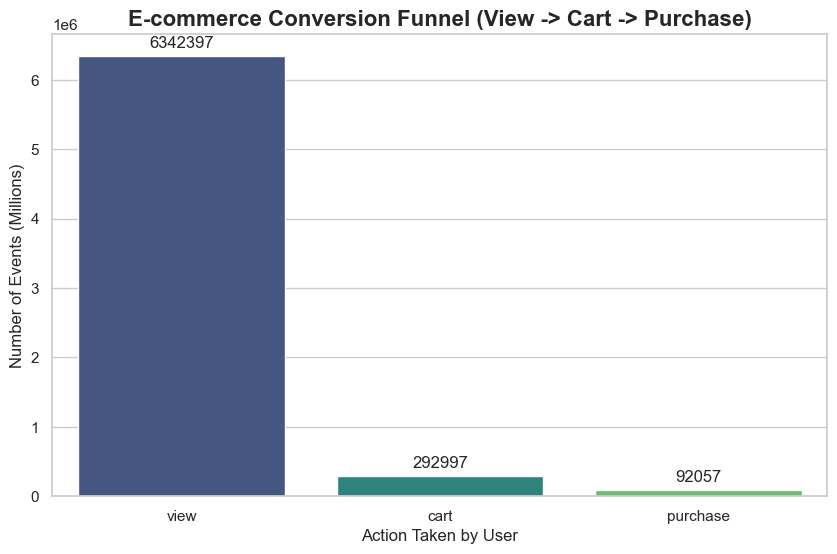

In [19]:
plt.figure(figsize=(10, 6))
# Event type ke counts nikal rahe hain
funnel_data = final_df['event_type'].value_counts().reset_index()
funnel_data.columns = ['Event', 'Count']

# Order set kar rahe hain Funnel flow ke hisaab se
order = ['view', 'cart', 'purchase']

ax = sns.barplot(x='Event', y='Count', data=funnel_data, order=order, palette="viridis")
plt.title('E-commerce Conversion Funnel (View -> Cart -> Purchase)', fontsize=16, fontweight='bold')
plt.xlabel('Action Taken by User', fontsize=12)
plt.ylabel('Number of Events (Millions)', fontsize=12)

# Bars ke upar exact number likhne ke liye
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()

In [20]:
funnel_data

,Event,Count
0,view,6342397
1,cart,292997
2,purchase,92057


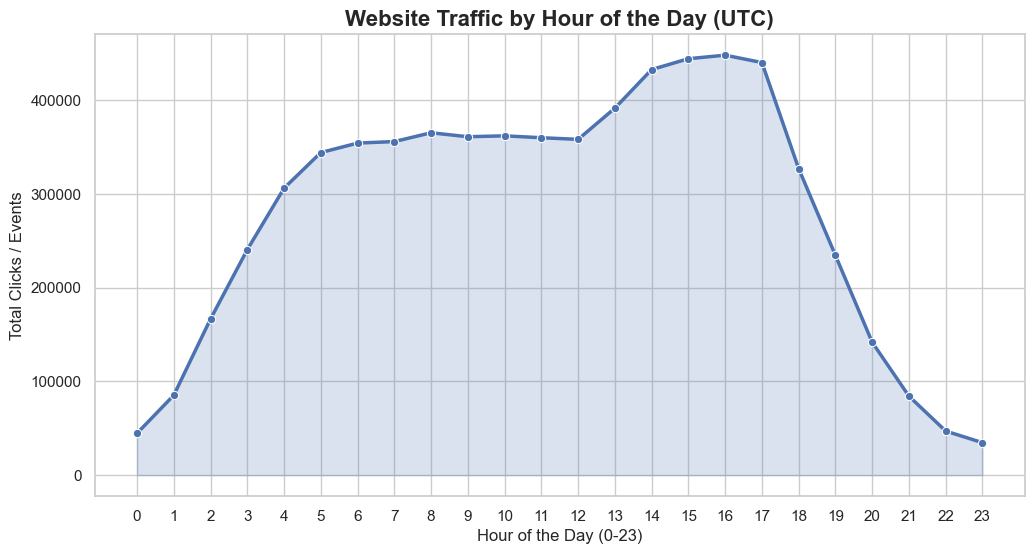

In [21]:
plt.figure(figsize=(12, 6))

# event_time se hour extract kar rahe hain
final_df['hour'] = final_df['event_time'].dt.hour
hourly_traffic = final_df['hour'].value_counts().sort_index().reset_index()
hourly_traffic.columns = ['Hour', 'Traffic_Count']

sns.lineplot(x='Hour', y='Traffic_Count', data=hourly_traffic, marker='o', color='b', linewidth=2.5)
plt.title('Website Traffic by Hour of the Day (UTC)', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Total Clicks / Events', fontsize=12)
plt.xticks(range(0, 24)) # X-axis par saare ghante dikhane ke liye
plt.fill_between(hourly_traffic['Hour'], hourly_traffic['Traffic_Count'], alpha=0.2, color='b')

plt.show()

In [22]:
hourly_traffic

,Hour,Traffic_Count
0,0,44647
1,1,85246
2,2,166584
3,3,240484
4,4,306058
5,5,344029
6,6,354125
7,7,355744
8,8,365111
9,9,360892


C:\Users\asus\AppData\Local\Temp\ipykernel_17028\2362239005.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_viewed.values, y=top_viewed.index, ax=axes[0], palette='Blues_r')
C:\Users\asus\AppData\Local\Temp\ipykernel_17028\2362239005.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_purchased.values, y=top_purchased.index, ax=axes[1], palette='Greens_r')


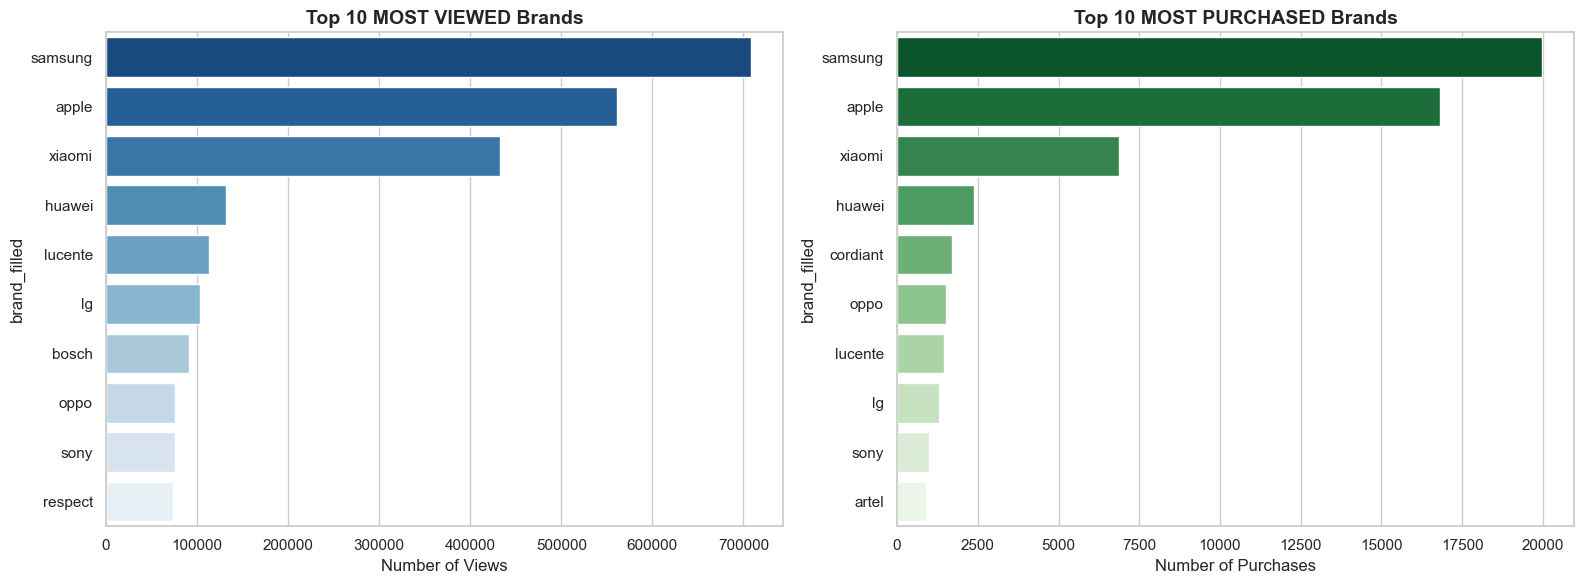

In [23]:
# 'unbranded' ko filter kar rahe hain actual brand insights ke liye
branded_df = final_df[final_df['brand_filled'] != 'unbranded']

# Top 10 Viewed Brands
top_viewed = branded_df[branded_df['event_type'] == 'view']['brand_filled'].value_counts().head(10)

# Top 10 Purchased Brands
top_purchased = branded_df[branded_df['event_type'] == 'purchase']['brand_filled'].value_counts().head(10)

# 2 subplots banayenge aamne-saamne compare karne ke liye
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Graph: Views
sns.barplot(x=top_viewed.values, y=top_viewed.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 MOST VIEWED Brands', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Views')

# Right Graph: Purchases
sns.barplot(x=top_purchased.values, y=top_purchased.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 MOST PURCHASED Brands', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Purchases')

plt.tight_layout()
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_17028\1521671410.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='event_type', y='price', data=price_data, palette='Set2', showfliers=False)


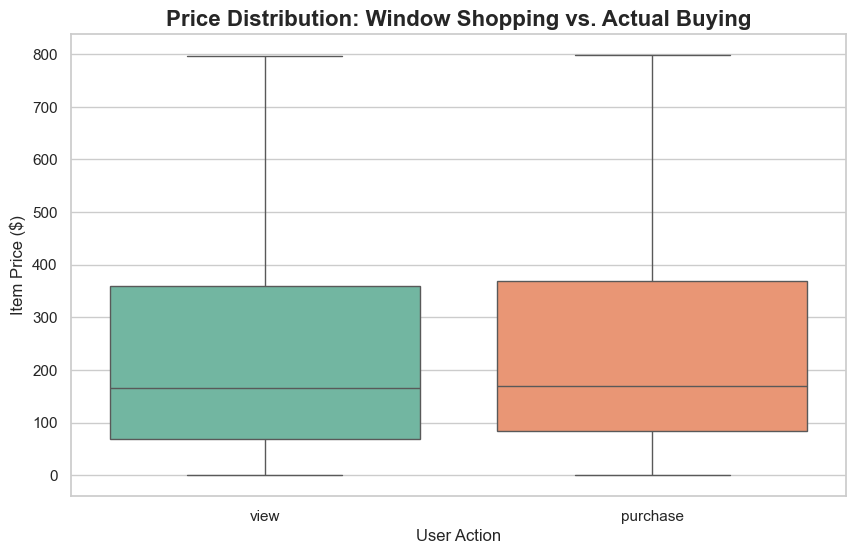

In [24]:
plt.figure(figsize=(10, 6))

# Hum sirf view aur purchase ko compare karenge
price_data = final_df[final_df['event_type'].isin(['view', 'purchase'])]

# Boxplot bana rahe hain (showfliers=False extreme outliers ko hide kar deta hai clean graph ke liye)
sns.boxplot(x='event_type', y='price', data=price_data, palette='Set2', showfliers=False)

plt.title('Price Distribution: Window Shopping vs. Actual Buying', fontsize=16, fontweight='bold')
plt.xlabel('User Action', fontsize=12)
plt.ylabel('Item Price ($)', fontsize=12)

plt.show()

In [27]:
final_df.head(20)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
0,2019-11-02 13:29:04+00:00,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e,construction.tools.drill,bosch,13
1,2019-11-01 19:06:53+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
2,2019-11-01 19:07:11+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
3,2019-11-01 19:08:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
4,2019-11-01 19:09:55+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
5,2019-11-01 19:11:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
6,2019-11-01 19:12:49+00:00,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
7,2019-11-01 19:13:17+00:00,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
8,2019-11-01 19:14:07+00:00,view,5100855,2053013553341792533,electronics.clocks,apple,548.02,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.clocks,apple,19
9,2019-11-01 19:14:58+00:00,view,1005073,2053013555631882655,electronics.smartphone,samsung,1133.09,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19


TRUE_CONVERSION_RATE:

C:\Users\asus\AppData\Local\Temp\ipykernel_17028\2981170350.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='User Action', y='Unique Users Count', data=population_data, palette=['#4C72B0', '#55A868'])


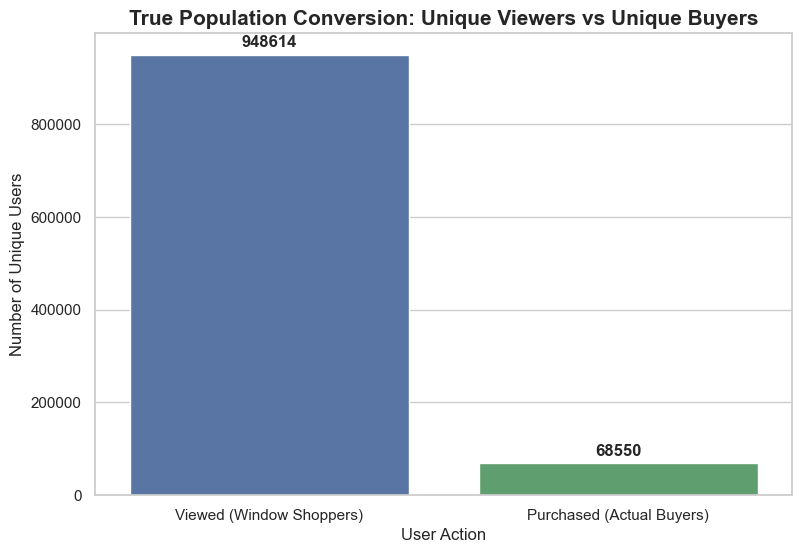

--------------------------------------------------
Total Unique Viewers : 948614
Total Unique Buyers  : 68550
True Population Conversion Rate : 7.23%
--------------------------------------------------


In [28]:

# STEP 1: Sirf unique users count nikalna (Bina original data change kiye)
# Kitne unique users ne kam se kam 1 baar 'view' kiya
unique_viewers = final_df[final_df['event_type'] == 'view']['user_id'].nunique()

# Kitne unique users ne kam se kam 1 baar 'purchase' kiya
unique_buyers = final_df[final_df['event_type'] == 'purchase']['user_id'].nunique()

# STEP 2: Graph ke liye chota sa temporary dataframe banana
population_data = pd.DataFrame({
    'User Action': ['Viewed (Window Shoppers)', 'Purchased (Actual Buyers)'],
    'Unique Users Count': [unique_viewers, unique_buyers]
})

# STEP 3: Graph Plot Karna
plt.figure(figsize=(9, 6))
ax = sns.barplot(x='User Action', y='Unique Users Count', data=population_data, palette=['#4C72B0', '#55A868'])

plt.title('True Population Conversion: Unique Viewers vs Unique Buyers', fontsize=15, fontweight='bold')
plt.ylabel('Number of Unique Users', fontsize=12)

# Bars ke upar exact number likhna taaki clear dikhe
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.show()

# STEP 4: Asali Conversion Rate Print Karna
conversion_rate = (unique_buyers / unique_viewers) * 100
print("-" * 50)
print(f"Total Unique Viewers : {unique_viewers}")
print(f"Total Unique Buyers  : {unique_buyers}")
print(f"True Population Conversion Rate : {conversion_rate:.2f}%")
print("-" * 50)

C:\Users\asus\AppData\Local\Temp\ipykernel_17028\3550965722.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Action Taken by User', y='Unique Users Count', data=population_funnel, palette=['#4C72B0', '#DD8452', '#55A868'])


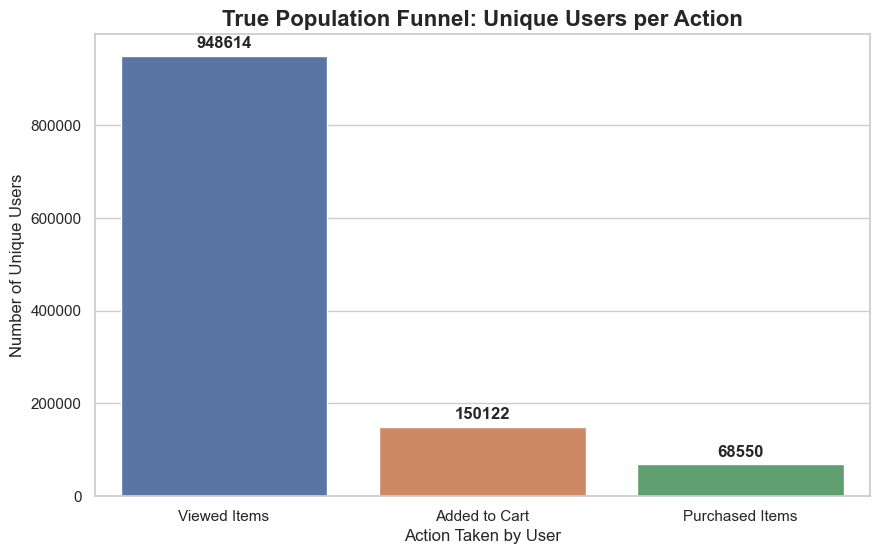

------------------------------------------------------------
🎯 TRUE POPULATION CONVERSION METRICS 🎯
------------------------------------------------------------
1. View-to-Cart Conversion : 15.83% (Kitne log cart tak pahuche)
2. Cart-to-Purchase Rate   : 45.66% (Inhone cart banaya aur kharida)
3. CART ABANDONMENT RATE   : 54.34% (Inhone cart me daala par kharida nahi!)
4. Final Overall Conversion: 7.23% (Total success rate)
------------------------------------------------------------


In [ ]:
# STEP 1: Teeno Actions ke liye Unique Users nikalna
unique_viewers = final_df[final_df['event_type'] == 'view']['user_id'].nunique()
unique_carters = final_df[final_df['event_type'] == 'cart']['user_id'].nunique()
unique_buyers = final_df[final_df['event_type'] == 'purchase']['user_id'].nunique()

# STEP 2: Graph ke liye DataFrame banana
population_funnel = pd.DataFrame({
    'Action Taken by User': ['Viewed Items', 'Added to Cart', 'Purchased Items'],
    'Unique Users Count': [unique_viewers, unique_carters, unique_buyers]
})

# STEP 3: Graph Plot Karna
plt.figure(figsize=(10, 6))
# Colors: Blue (View), Orange (Cart), Green (Purchase)
ax = sns.barplot(x='Action Taken by User', y='Unique Users Count', data=population_funnel, palette=['#4C72B0', '#DD8452', '#55A868'])

plt.title('True Population Funnel: Unique Users per Action', fontsize=16, fontweight='bold')
plt.ylabel('Number of Unique Users', fontsize=12)

# Bars ke upar exact number likhna
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.show()

# STEP 4: Deep Business Metrics Print Karna
print("-" * 60)
print(" TRUE POPULATION CONVERSION METRICS ")
print("-" * 60)
if unique_viewers > 0:
    print(f"1. View-to-Cart Conversion : {(unique_carters / unique_viewers) * 100:.2f}% (Kitne log cart tak pahuche)")
if unique_carters > 0:
    print(f"2. Cart-to-Purchase Rate   : {(unique_buyers / unique_carters) * 100:.2f}% (Inhone cart banaya aur kharida)")
    print(f"3. CART ABANDONMENT RATE   : {(1 - (unique_buyers / unique_carters)) * 100:.2f}% (Inhone cart me daala par kharida nahi!)")
if unique_viewers > 0:
    print(f"4. Final Overall Conversion: {(unique_buyers / unique_viewers) * 100:.2f}% (Total success rate)")
print("-" * 60)

In [30]:
final_df.head(6)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
0,2019-11-02 13:29:04+00:00,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e,construction.tools.drill,bosch,13
1,2019-11-01 19:06:53+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
2,2019-11-01 19:07:11+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
3,2019-11-01 19:08:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
4,2019-11-01 19:09:55+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
5,2019-11-01 19:11:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19


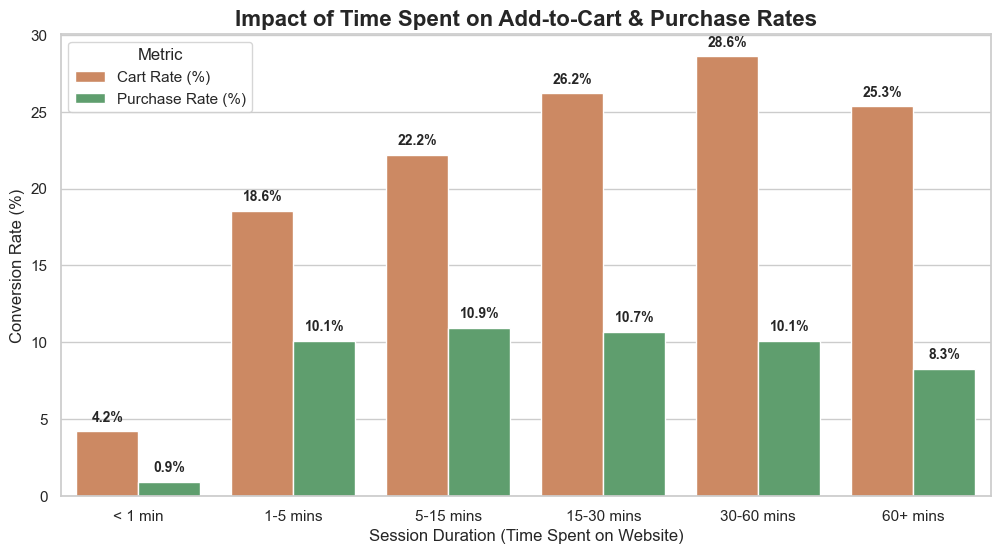

In [31]:
# STEP 1: Har session ka start time aur end time nikalna (Fast Groupby)
session_time = final_df.groupby('user_session').agg(
    start_time=('event_time', 'min'),
    end_time=('event_time', 'max')
)

# Duration minutes mein calculate karna
session_time['duration_minutes'] = (session_time['end_time'] - session_time['start_time']).dt.total_seconds() / 60

# STEP 2: Identify karna ki kis session mein Cart ya Purchase hua
cart_sessions = set(final_df[final_df['event_type'] == 'cart']['user_session'])
purchase_sessions = set(final_df[final_df['event_type'] == 'purchase']['user_session'])

session_time['has_cart'] = session_time.index.isin(cart_sessions)
session_time['has_purchase'] = session_time.index.isin(purchase_sessions)

# STEP 3: Time Buckets banana (0-1 min, 1-5 mins, etc.)
bins = [-1, 1, 5, 15, 30, 60, np.inf]
labels = ['< 1 min', '1-5 mins', '5-15 mins', '15-30 mins', '30-60 mins', '60+ mins']
session_time['time_bucket'] = pd.cut(session_time['duration_minutes'], bins=bins, labels=labels)

# STEP 4: Har bucket ka Cart aur Purchase Percentage (Conversion Rate) calculate karna
bucket_stats = session_time.groupby('time_bucket', observed=True).agg(
    total_sessions=('duration_minutes', 'count'),
    cart_count=('has_cart', 'sum'),
    purchase_count=('has_purchase', 'sum')
)

# Percentages nikalna
bucket_stats['Cart Rate (%)'] = (bucket_stats['cart_count'] / bucket_stats['total_sessions']) * 100
bucket_stats['Purchase Rate (%)'] = (bucket_stats['purchase_count'] / bucket_stats['total_sessions']) * 100
bucket_stats = bucket_stats.reset_index()

# Graph ke liye data ko reshape karna (Melting)
plot_data = pd.melt(bucket_stats, id_vars='time_bucket', 
                    value_vars=['Cart Rate (%)', 'Purchase Rate (%)'], 
                    var_name='Metric', value_name='Rate')

# STEP 5: Graph Plot Karna
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='time_bucket', y='Rate', hue='Metric', data=plot_data, palette=['#DD8452', '#55A868'])

plt.title('Impact of Time Spent on Add-to-Cart & Purchase Rates', fontsize=16, fontweight='bold')
plt.xlabel('Session Duration (Time Spent on Website)', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)

# Bars ke upar exact percentage likhna
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Sirf un bars par number likho jinki height 0 se zyada hai
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.show()

In [32]:
final_df.to_csv('Final_Cleaned_Dataset_with_sorting.csv', index=False)

Paise ke basis par

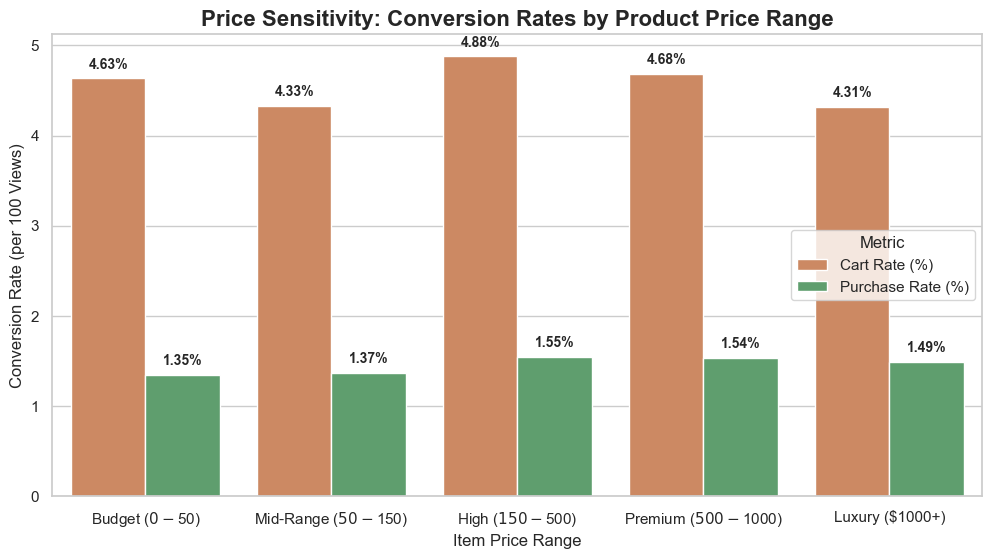

In [33]:
# STEP 1: Price Buckets Banana
# Hum prices ko logical ranges mein divide kar rahe hain (e-commerce standard)
bins = [0, 50, 150, 500, 1000, np.inf]
labels = ['Budget ($0-$50)', 'Mid-Range ($50-$150)', 'High ($150-$500)', 'Premium ($500-$1000)', 'Luxury ($1000+)']

# Naya column add kar rahe hain price buckets ke liye
final_df['price_bucket'] = pd.cut(final_df['price'], bins=bins, labels=labels)

# STEP 2: Har Price Bucket mein View, Cart, aur Purchase count karna
price_stats = final_df.groupby(['price_bucket', 'event_type'], observed=True).size().unstack(fill_value=0)

# STEP 3: Conversion Rates Calculate Karna (Out of total views in that bucket)
price_stats['Cart Rate (%)'] = (price_stats['cart'] / price_stats['view']) * 100
price_stats['Purchase Rate (%)'] = (price_stats['purchase'] / price_stats['view']) * 100
price_stats = price_stats.reset_index()

# Graph ke liye data ko reshape karna
plot_data = pd.melt(price_stats, id_vars='price_bucket', 
                    value_vars=['Cart Rate (%)', 'Purchase Rate (%)'], 
                    var_name='Metric', value_name='Rate')

# STEP 4: Graph Plot Karna
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='price_bucket', y='Rate', hue='Metric', data=plot_data, palette=['#DD8452', '#55A868'])

plt.title('Price Sensitivity: Conversion Rates by Product Price Range', fontsize=16, fontweight='bold')
plt.xlabel('Item Price Range', fontsize=12)
plt.ylabel('Conversion Rate (per 100 Views)', fontsize=12)

# Bars ke upar exact percentage likhna
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.show()